# Baseline Projections — PCA, t-SNE, UMAP

Projection plots for the selected scenarios from both baselines:

- **FFS** (Fast Forward Selection) — k=20, k=100
- **WL Kernel + k-Medoids** — k=20, k=100


In [1]:
import os, json, glob, pickle, hashlib, gc
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

import umap


In [2]:
GRAPHS_DIR  = '/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/graphs'
RESULTS_DIR = '/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/src/baselines/results'
GRID_SIZE, N_CELLS, N_TOTAL = 20, 400, 49_125

results = {}
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.json'):
        with open(os.path.join(RESULTS_DIR, fname)) as f:
            d = json.load(f)
        method = 'FFS' if 'fss' in fname else 'WL'
        results[(method, d['k'])] = d
        print(f'{method} k={d["k"]:>3d}  |  selected={len(d["selected_indices"])}  |  total={d["total_graphs"]}')

graph_files = sorted(glob.glob(os.path.join(GRAPHS_DIR, 'graph_*.pickle')))
assert len(graph_files) == N_TOTAL
print(f'\n{len(graph_files)} graph files')

WL k=100  |  selected=100  |  total=49125
WL k= 20  |  selected=20  |  total=49125
FFS k=100  |  selected=100  |  total=49125
FFS k= 20  |  selected=20  |  total=49125

49125 graph files


In [ ]:
fss_20=results[ ('FFS', 20)]
fss_20.keys()
fss_20["cluster_labels"]


49125

## Stratified sample (~8k points, all medoids included)


In [3]:
rng = np.random.RandomState(42)
must_include = set()
for res in results.values():
    must_include.update(res['selected_indices'])

wl100_labels = np.array(results[('WL', 100)]['cluster_labels'])
pool = np.array([i for i in range(N_TOTAL) if i not in must_include])
remaining = 8000 - len(must_include)
chosen = []
for c in range(100):
    mask = wl100_labels[pool] == c
    n_from = max(1, int(remaining * mask.sum() / len(pool)))
    cands = pool[mask]
    if len(cands) > 0:
        chosen.append(rng.choice(cands, min(n_from, len(cands)), replace=False))

sample_idx = np.sort(np.unique(np.concatenate([list(must_include), np.concatenate(chosen)]).astype(int)))
SAMPLE_N = len(sample_idx)
g2l = {g: l for l, g in enumerate(sample_idx)}
sample_set = set(sample_idx)
print(f'Sample: {SAMPLE_N} points ({len(must_include)} medoids + {SAMPLE_N - len(must_include)} stratified)')

Sample: 7959 points (219 medoids + 7740 stratified)


## Feature extraction (burn-scar + WL hash)


In [4]:
burn_matrix = np.zeros((SAMPLE_N, N_CELLS), dtype=np.float32)
for i in tqdm(range(N_TOTAL), desc='Burn scars', mininterval=2):
    if i not in sample_set:
        continue
    G = pickle.load(open(graph_files[i], 'rb'))
    valid = [int(n) for n in G.nodes() if 0 <= int(n) < N_CELLS]
    burn_matrix[g2l[i], valid] = 1.0
    del G
print(f'Burn matrix: {burn_matrix.shape}')

Burn scars:   0%|          | 0/49125 [00:00<?, ?it/s]

Burn scars: 100%|██████████| 49125/49125 [00:01<00:00, 31570.28it/s]

Burn matrix: (7959, 400)


In [5]:
WL_ITERS, HASH_DIM = 3, 2**14

def _hb(s, dim):
    return int(hashlib.md5(s.encode()).hexdigest(), 16) % dim
def _hs(s):
    return 1 if int(hashlib.md5((s+'_s').encode()).hexdigest(), 16) % 2 == 0 else -1

def wl_feat(G):
    nodes = list(G.nodes())
    if not nodes:
        return np.zeros(HASH_DIM, dtype=np.float32)
    lab = {n: f'{G.in_degree(n)}_{G.out_degree(n)}' for n in nodes}
    vec = np.zeros(HASH_DIM, dtype=np.float32)
    for n in nodes:
        vec[_hb(f'i0_{lab[n]}', HASH_DIM)] += _hs(f'i0_{lab[n]}')
    for it in range(1, WL_ITERS+1):
        nl = {}
        for n in nodes:
            sig = f'{lab[n]}|I:{".".join(sorted(lab[u] for u in G.predecessors(n)))}|O:{".".join(sorted(lab[v] for v in G.successors(n)))}'
            nl[n] = sig
            vec[_hb(f'i{it}_{sig}', HASH_DIM)] += _hs(f'i{it}_{sig}')
        lab = nl
    return vec

wl_dense = np.zeros((SAMPLE_N, HASH_DIM), dtype=np.float32)
for i in tqdm(range(N_TOTAL), desc='WL hashing', mininterval=2):
    if i not in sample_set:
        continue
    G = pickle.load(open(graph_files[i], 'rb'))
    wl_dense[g2l[i]] = wl_feat(G)
    del G

wl_normed = normalize(wl_dense, norm='l2', axis=1)
del wl_dense; gc.collect()
print(f'WL matrix: {wl_normed.shape}')

WL hashing: 100%|██████████| 49125/49125 [00:18<00:00, 2721.04it/s]

WL matrix: (7959, 16384)


## Dimensionality reduction


In [6]:
pca_burn = PCA(n_components=50, random_state=42).fit_transform(burn_matrix)
pca_wl   = PCA(n_components=50, random_state=42).fit_transform(wl_normed)
print('PCA done')

PCA done


In [7]:
tsne_burn = TSNE(n_components=2, perplexity=50, random_state=42, max_iter=1000,
                 init='pca', learning_rate='auto').fit_transform(pca_burn)
tsne_wl   = TSNE(n_components=2, perplexity=50, random_state=42, max_iter=1000,
                 init='pca', learning_rate='auto').fit_transform(pca_wl)
print('t-SNE done')

t-SNE done


## Plotting


In [9]:
import colorsys

def make_palette(n):
    """Generate n maximally-separated, vivid colours."""
    if n <= 20:
        # hand-picked vivid 20-colour palette
        base = [
            '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
            '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990',
            '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3',
            '#808000', '#ffd8b1', '#000075', '#a9a9a9', '#e6beff',
        ]
        return [base[i % len(base)] for i in range(n)]
    else:
        # HSV sweep for k=100: high saturation, two brightness levels for contrast
        colors = []
        for i in range(n):
            hue = (i * 0.618033988749895) % 1.0   # golden-ratio spacing
            sat = 0.75 + 0.25 * (i % 2)
            val = 0.85 - 0.15 * (i % 3 == 0)
            colors.append(colorsys.hsv_to_rgb(hue, sat, val))
        return colors

def plot_proj(ax, coords, labels, sel_global, title):
    n_c = len(set(labels[labels >= 0]))
    palette = make_palette(n_c)
    colors = np.array([palette[int(l) % n_c] for l in labels])

    # draw non-selected points
    sel_set = set(g2l[g] for g in sel_global if g in g2l)
    mask_bg = np.array([i not in sel_set for i in range(len(labels))])

    ax.scatter(coords[mask_bg, 0], coords[mask_bg, 1],
               c=colors[mask_bg], s=6, alpha=0.55, edgecolors='none', rasterized=True)

    # selected medoids: white halo + coloured fill + black edge
    local_sel = sorted(sel_set)
    if local_sel:
        # halo
        ax.scatter(coords[local_sel, 0], coords[local_sel, 1],
                   c='white', s=120, marker='o', edgecolors='none', zorder=4, alpha=0.9)
        # star
        ax.scatter(coords[local_sel, 0], coords[local_sel, 1],
                   c='#FFD700', s=80, marker='*',
                   edgecolors='#222222', linewidths=0.7, zorder=5)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
        spine.set_linewidth(0.5)
    ax.set_facecolor('#fafafa')


def proj_row(projs, labels, sel, suptitle, figsize=(20, 6)):
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, (name, c) in zip(axes, projs.items()):
        plot_proj(ax, c, labels, sel, name)

    legend_handles = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#FFD700',
               markeredgecolor='#222222', markersize=14, label='Selected representative'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#cccccc',
               markeredgecolor='none', markersize=7, alpha=0.7, label='Scenario (coloured by cluster)')
    ]
    axes[-1].legend(handles=legend_handles, loc='lower right', fontsize=9,
                    framealpha=0.9, edgecolor='#cccccc')

    fig.suptitle(suptitle, fontsize=15, fontweight='bold', y=1.03)
    fig.patch.set_facecolor('white')
    fig.tight_layout()
    return fig

print('Plotting utilities ready')

Plotting utilities ready


## FFS — k=20


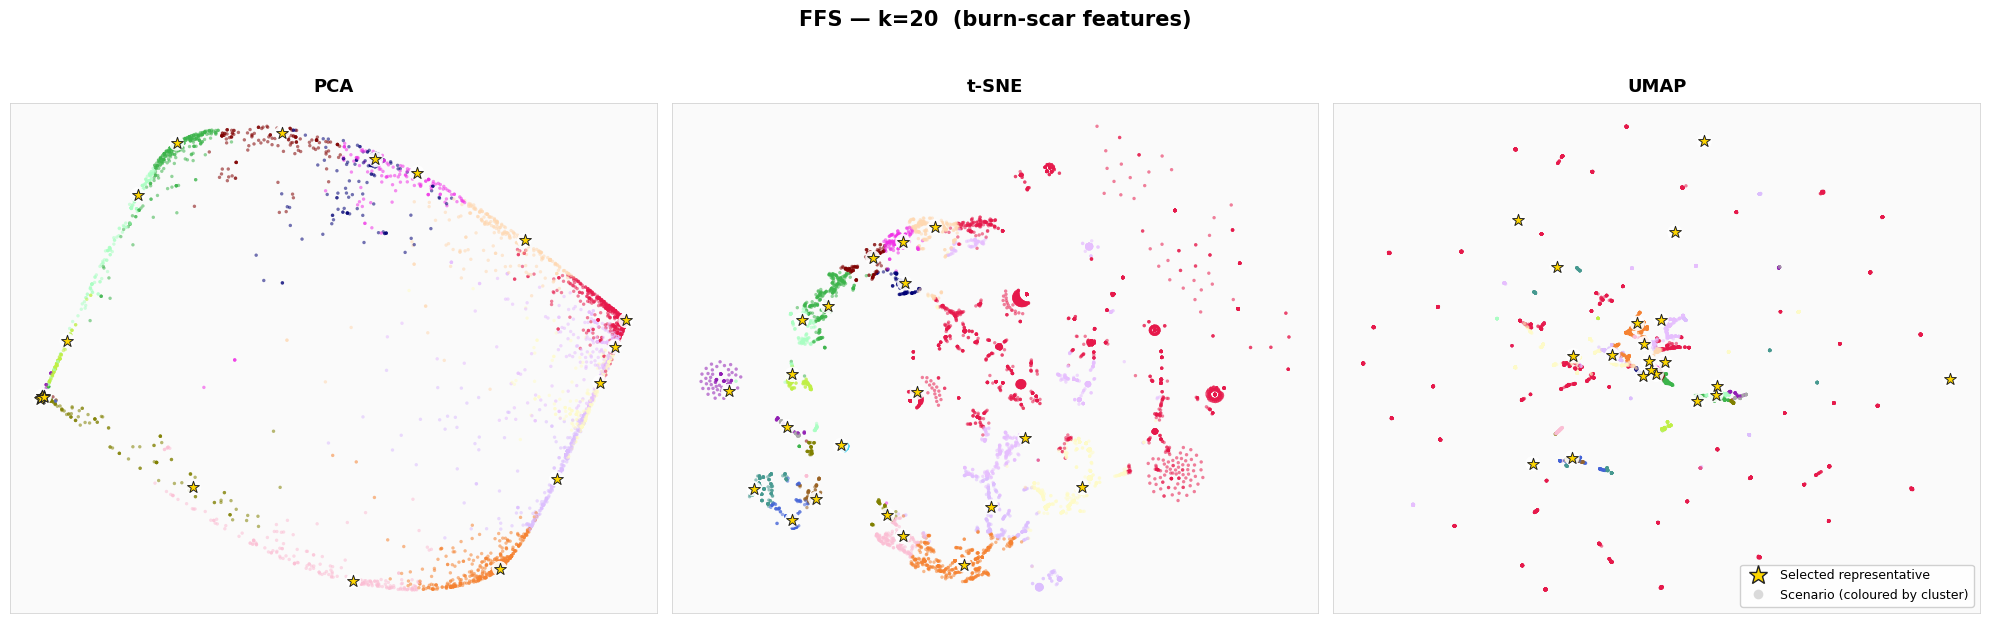

In [10]:
r = results[('FFS', 20)]
lab = np.array(r['cluster_labels'])[sample_idx]
proj_row({'PCA': pca_burn[:,:2], 't-SNE': tsne_burn, 'UMAP': umap_burn},
         lab, r['selected_indices'], 'FFS — k=20  (burn-scar features)')
plt.show()

## FFS — k=100


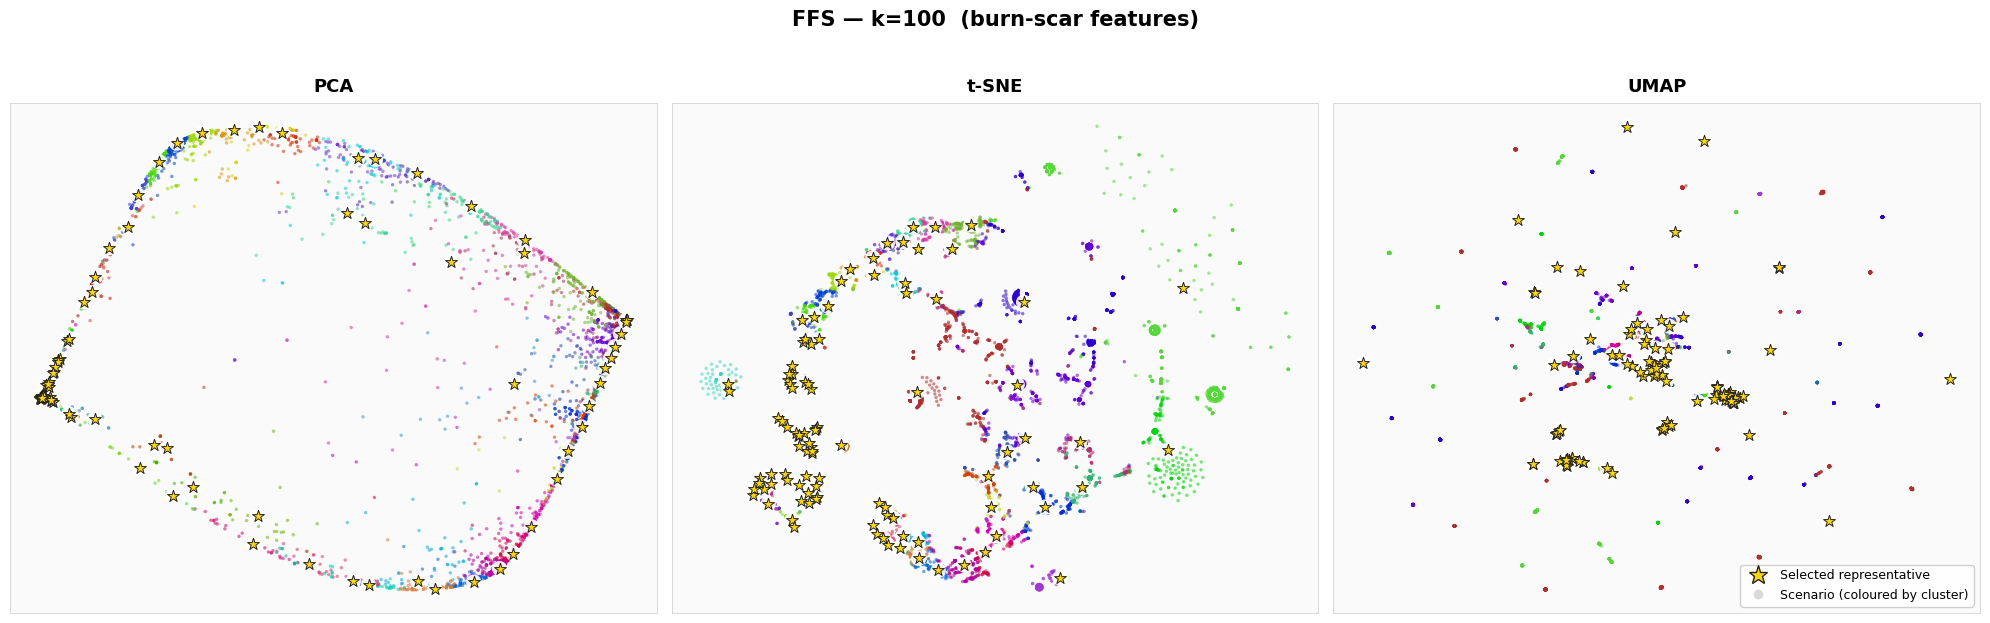

In [11]:
r = results[('FFS', 100)]
lab = np.array(r['cluster_labels'])[sample_idx]
proj_row({'PCA': pca_burn[:,:2], 't-SNE': tsne_burn, 'UMAP': umap_burn},
         lab, r['selected_indices'], 'FFS — k=100  (burn-scar features)')
plt.show()

## WL Kernel + k-Medoids — k=20


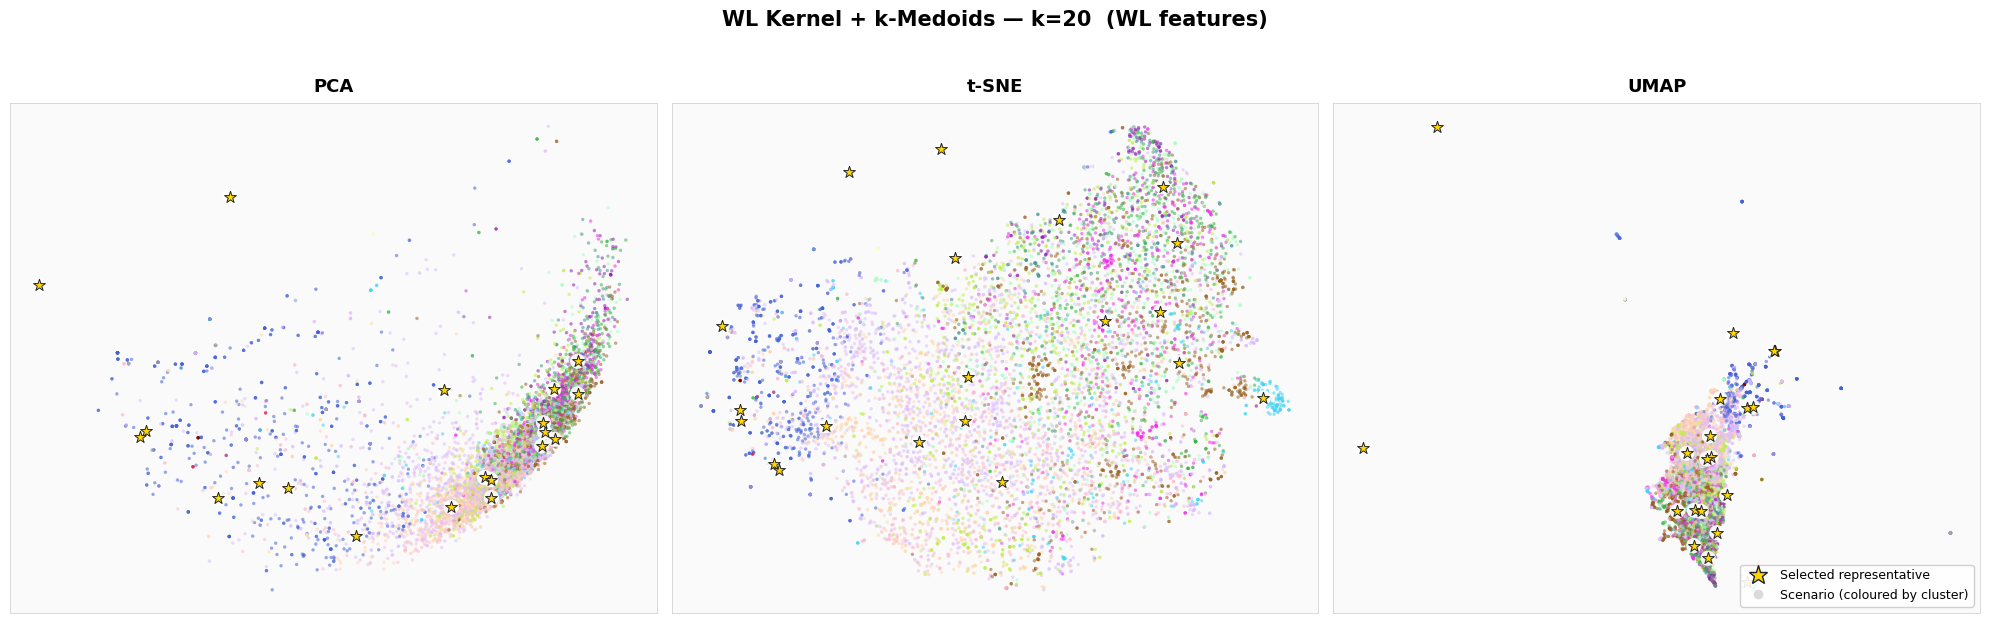

In [12]:
r = results[('WL', 20)]
lab = np.array(r['cluster_labels'])[sample_idx]
proj_row({'PCA': pca_wl[:,:2], 't-SNE': tsne_wl, 'UMAP': umap_wl},
         lab, r['selected_indices'], 'WL Kernel + k-Medoids — k=20  (WL features)')
plt.show()

## WL Kernel + k-Medoids — k=100


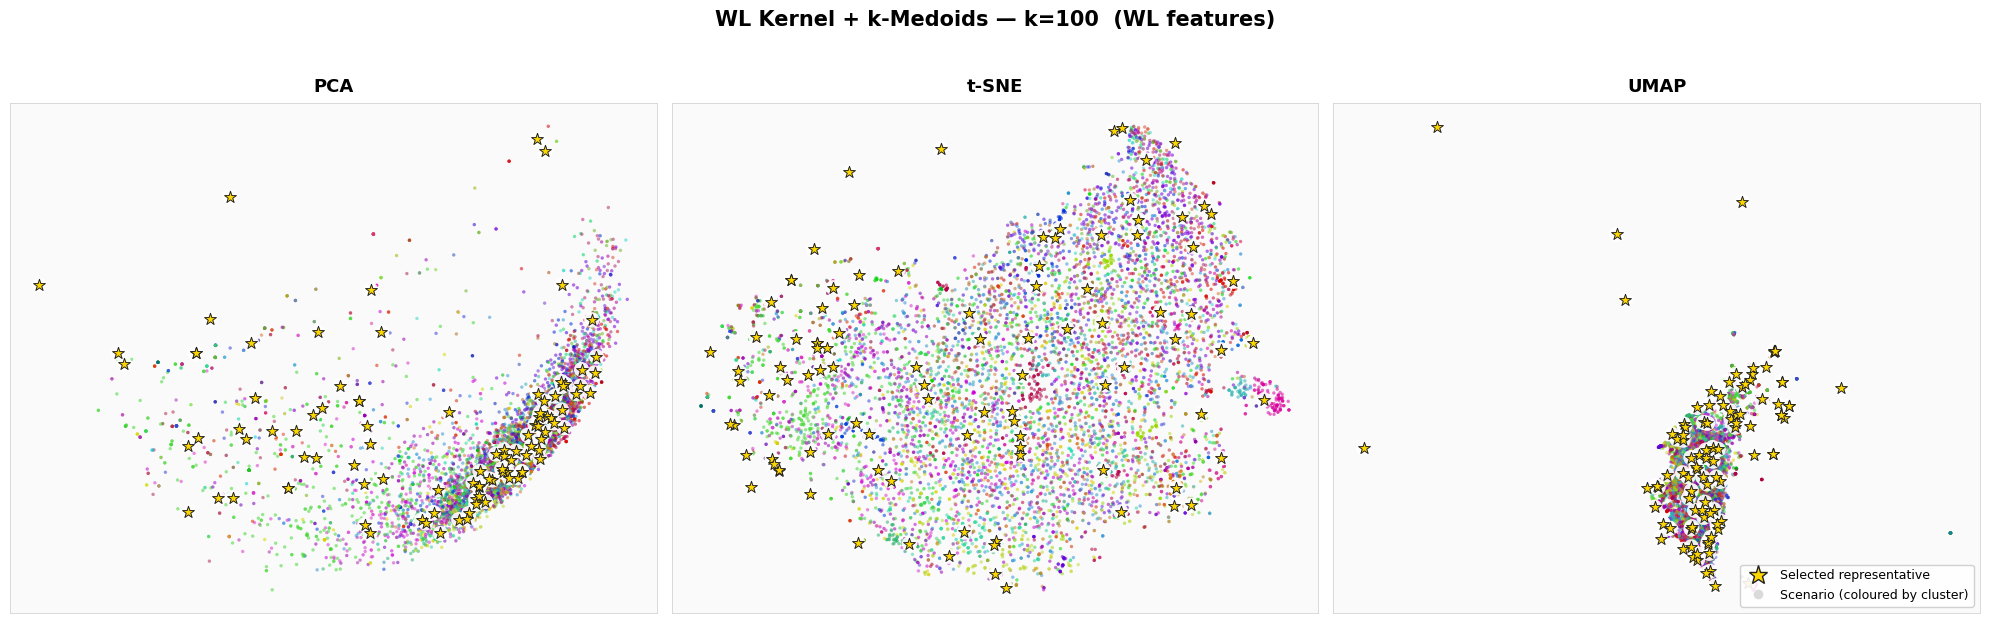

In [13]:
r = results[('WL', 100)]
lab = np.array(r['cluster_labels'])[sample_idx]
proj_row({'PCA': pca_wl[:,:2], 't-SNE': tsne_wl, 'UMAP': umap_wl},
         lab, r['selected_indices'], 'WL Kernel + k-Medoids — k=100  (WL features)')
plt.show()